##### Copyright 2018 The TensorFlow Authors.

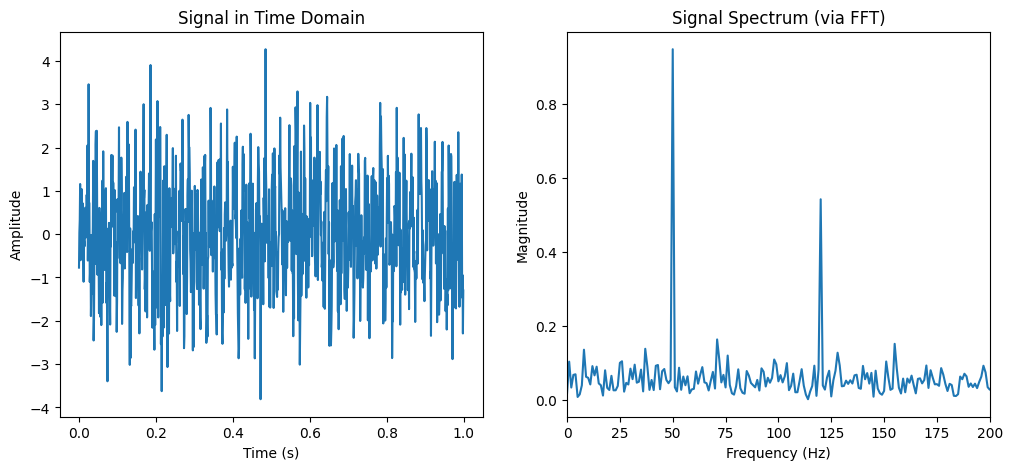

In [17]:
import numpy as np
import matplotlib.pyplot as plt

sampling_rate = 1000
T = 1.0
N = int(sampling_rate * T)
t = np.linspace(0.0, T, N, endpoint=False)

freq1 = 50
freq2 = 120
#add random noise
signal = np.sin(freq1 * 2.0*np.pi * t) + 0.5*np.sin(freq2 * 2.0*np.pi *t) + np.random.randn(N)


signal_fft = np.fft.fft(signal)
fft_magnitude = 2.0/N * np.abs(signal_fft[0:N//2])

freq_axis = np.fft.fftfreq(N, 1/sampling_rate)[:N//2]

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(t, signal)
plt.title("Signal in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.plot(freq_axis, fft_magnitude)
plt.title("Signal Spectrum (via FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 200)

plt.show()

#exercise 1 question answer: I can still see the 50 HZ and 120 HZ peaks and
#the added noise appears as a random background with varying magnitudes across frequencies,


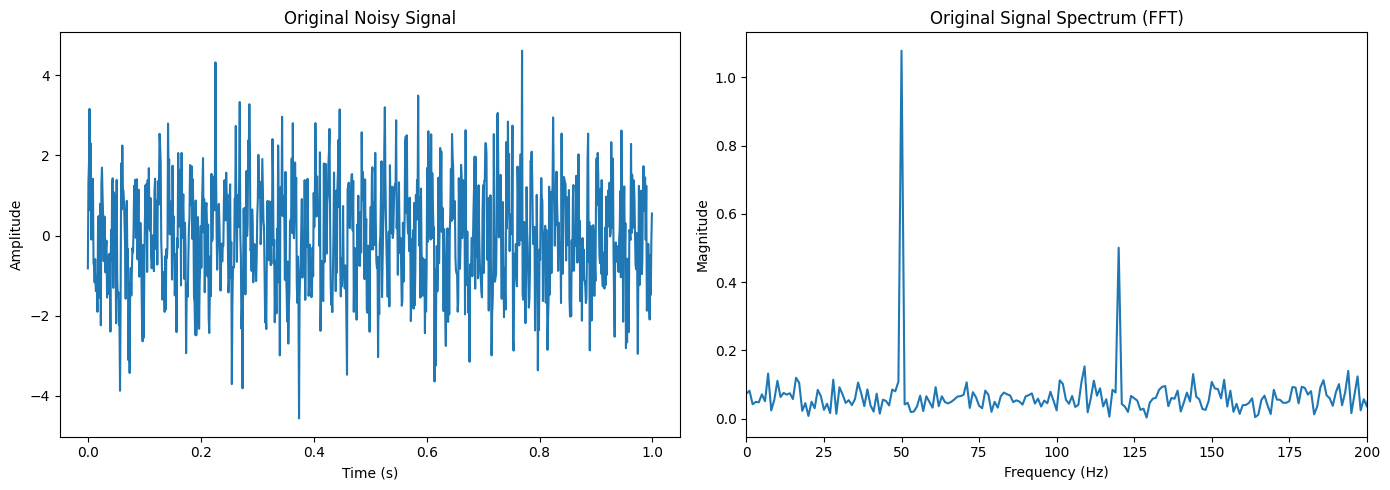

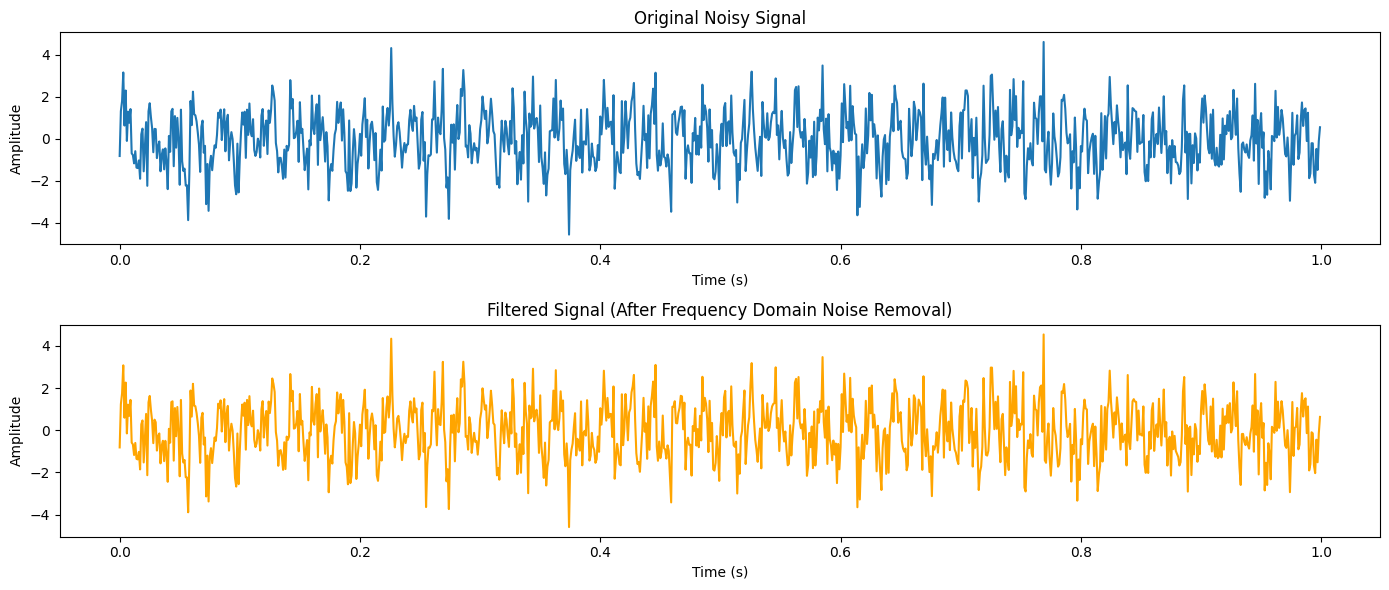

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create noisy signal
sampling_rate = 1000
T = 1.0
N = int(sampling_rate * T)
t = np.linspace(0.0, T, N, endpoint=False)

# Original signal with noise
freq1 = 50
freq2 = 120
signal = np.sin(2*np.pi*freq1*t) + 0.5*np.sin(2*np.pi*freq2*t) + np.random.randn(N)

# Step 2: Take the FFT of the noisy signal
signal_fft = np.fft.fft(signal)

# Step 3: Zero out small magnitude values in the frequency domain
magnitude = np.abs(signal_fft)
threshold = 30  # Try changing this if needed
filtered_fft = signal_fft.copy()
filtered_fft[magnitude < threshold] = 0

# Step 4: Apply inverse FFT to get the cleaned signal
filtered_signal = np.fft.ifft(filtered_fft).real

# Step 5: Plot original and cleaned time-domain signals
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title("Original Noisy Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(t, filtered_signal, color='orange')
plt.title("Filtered Signal (After Zeroing Small FFT Magnitudes)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()



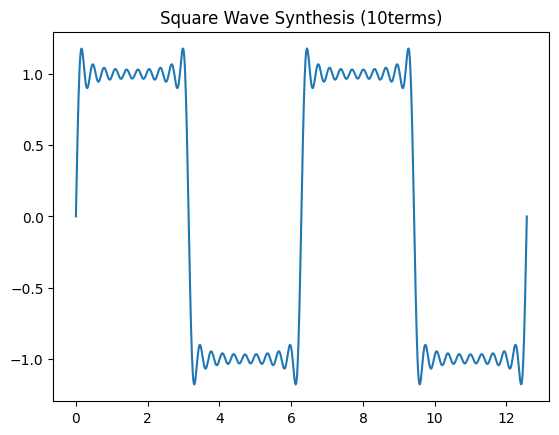

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#time array

t = np.linspace(0,4 * np.pi, 1000)
y = np.zeros_like(t)

# Number of harmonics to add
num_harmonics = 10

for i in range(num_harmonics):
  k = 2 * i + 1
  y+=(4 / (k * np.pi)) * np.sin(k * t)

plt.plot(t, y)
plt.title (f'Square Wave Synthesis ({num_harmonics}terms)')
plt.show()

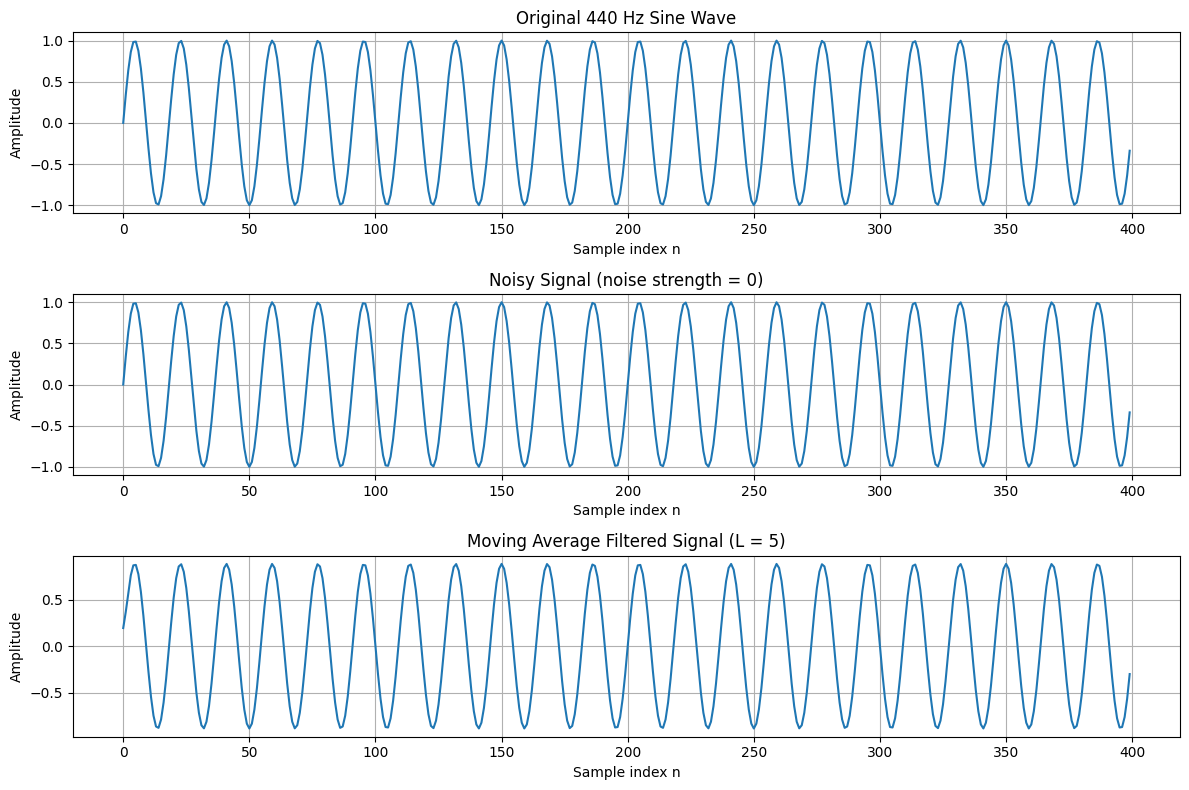

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 8000          # Sampling frequency
dur = 0.5          # Duration in seconds
f = 440.0          # Frequency of sine wave (Hz)
L = 5              # Moving average window length
noise_strength = 0  # adjust to increase noise

# Number of samples and sample indices
N = int(fs * dur)
n = np.arange(N)

# 1. Sine wave (your style)
x = np.sin(2 * np.pi * f * n / fs)

# 2. Add random noise
noise = noise_strength * np.random.randn(N)
x_noisy = x + noise

# 3. Moving average filter
kernel = np.ones(L) / L
y = np.convolve(x_noisy, kernel, mode='same')  # averaged signal

# 4. Plot
plt.figure(figsize=(12, 8))

plt.subplot(3,1,1)
plt.plot(n[:400], x[:400])  # first 400 samples
plt.title('Original 440 Hz Sine Wave')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(n[:400], x_noisy[:400])
plt.title(f'Noisy Signal (noise strength = {noise_strength})')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(n[:400], y[:400])
plt.title(f'Moving Average Filtered Signal (L = {L})')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def convolve1d(x, h):

    x = np.array(x)
    h = np.array(h)
    N = len(x)
    M = len(h)
    y = np.zeros(N + M - 1)
    for n in range(len(y)):
        for k in range(N):
            if 0 <= n - k < M:
                y[n] += x[k] * h[n - k]
    return y

def impulse_response(x_length):
    x = np.zeros(x_length)
    x[0] = 1.0

    y = np.zeros_like(x)

    for n in range(x_length):
        x_n = x[n]
        x_n1 = x[n-1] if n-1 >= 0 else 0
        y[n] = 0.5 * (x_n + x_n1)
    return y

x = np.array([1,2,3])
h = impulse_response(len(x))

y = convolve1d(x,h)

print(y)

[0.5 1.5 2.5 1.5 0. ]


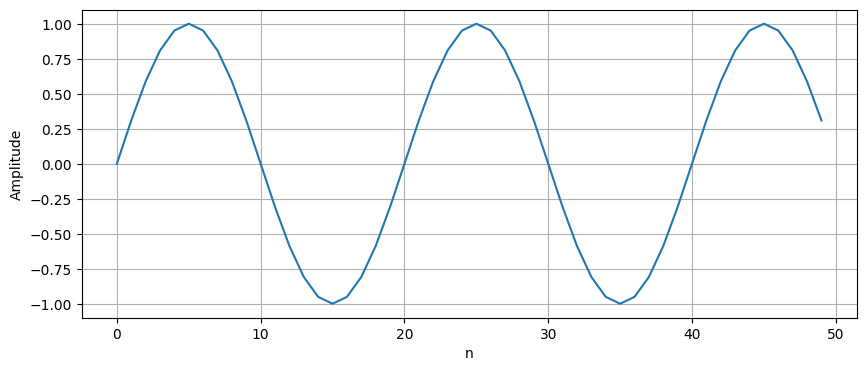

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fs = 8000
dur = 0.5
f = 400.0

N = int(fs * dur)
n = np.arange(N)
x = np.sin(2 * np.pi * f * n / fs)

plt.figure(figsize=(10, 4))
plt.plot(n[:50], x[:50])

plt.xlabel("n"); plt.ylabel("Amplitude"); plt.grid(True);plt.show()